In [ ]:
# Load libraries
import kagglehub
import pandas as pd
import seaborn as sns
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay, average_precision_score, roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from scipy import stats
from tensorflow import keras

In [ ]:
# Load data
kagglehub.login()
kagglehub.whoami()

Kaggle credentials successfully validated.


{'username': 'amnimhd'}

In [7]:
path = kagglehub.competition_download('home-credit-default-risk')
print("Path to competition files:", path)

Path to competition files: /Users/amanimohammed/.cache/kagglehub/competitions/home-credit-default-risk


In [ ]:
# Load files
test = pd.read_csv("application_test.csv")
train = pd.read_csv("application_train.csv")

bureau = pd.read_csv("bureau.csv")
bureau_balance = pd.read_csv("bureau_balance.csv")
previous = pd.read_csv("previous_application.csv")
pos_cash = pd.read_csv("POS_CASH_balance.csv")
credit_card = pd.read_csv("credit_card_balance.csv")
installments = pd.read_csv("installments_payments.csv")

In [ ]:
# 1. DATA ANALYSIS
display(train.head)
display(train.describe())

# Missing values
print("Missing values per column, training set:")
missing_train = train.isnull().sum()
missing_pct_train = (missing_train / len(train) * 100).sort_values(ascending=False)

display(missing_pct_train.head(30))

print("Missing values per column, test set:")
missing_test = test.isnull().sum()
missing_pct_test = (missing_test / len(test) * 100).sort_values(ascending=False)

display(missing_pct_test.head(30))

overall_missing_pct_train = train.isnull().sum().sum() / train.size * 100
print(f"Overall missing percentage, train: {overall_missing_pct_train:.2f}%")

overall_missing_pct_test = test.isnull().sum().sum() / test.size * 100
print(f"Overall missing percentage, test: {overall_missing_pct_test:.2f}%")

<bound method NDFrame.head of         SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0           100002       1         Cash loans           M            N   
1           100003       0         Cash loans           F            N   
2           100004       0    Revolving loans           M            Y   
3           100006       0         Cash loans           F            N   
4           100007       0         Cash loans           M            N   
...            ...     ...                ...         ...          ...   
307506      456251       0         Cash loans           M            N   
307507      456252       0         Cash loans           F            N   
307508      456253       0         Cash loans           F            N   
307509      456254       1         Cash loans           F            N   
307510      456255       0         Cash loans           F            N   

       FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  \
0          

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


Missing values per column, training set:


COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
BASEMENTAREA_MEDI           58.515956
BASEMENTAREA_AVG            58.515956
BASEMENTAREA_MODE           58.515956
EXT_SOURCE_1                56.381073
NONLIVINGAREA_MODE          55.179164
NONLIVINGAREA_AVG           55.179164
NONLIVINGARE

Missing values per column, test set:


COMMONAREA_AVG              68.716150
COMMONAREA_MODE             68.716150
COMMONAREA_MEDI             68.716150
NONLIVINGAPARTMENTS_AVG     68.412523
NONLIVINGAPARTMENTS_MODE    68.412523
NONLIVINGAPARTMENTS_MEDI    68.412523
FONDKAPREMONT_MODE          67.284179
LIVINGAPARTMENTS_AVG        67.249302
LIVINGAPARTMENTS_MODE       67.249302
LIVINGAPARTMENTS_MEDI       67.249302
FLOORSMIN_MEDI              66.605121
FLOORSMIN_AVG               66.605121
FLOORSMIN_MODE              66.605121
OWN_CAR_AGE                 66.289184
YEARS_BUILD_AVG             65.275726
YEARS_BUILD_MEDI            65.275726
YEARS_BUILD_MODE            65.275726
LANDAREA_MEDI               57.964057
LANDAREA_AVG                57.964057
LANDAREA_MODE               57.964057
BASEMENTAREA_MEDI           56.706466
BASEMENTAREA_AVG            56.706466
BASEMENTAREA_MODE           56.706466
NONLIVINGAREA_AVG           53.512227
NONLIVINGAREA_MODE          53.512227
NONLIVINGAREA_MEDI          53.512227
ELEVATORS_MO

Overall missing percentage, train: 24.40%
Overall missing percentage, test: 23.81%


In [10]:
# Feature engineering
train_df = train.copy()
test_df = test.copy()

# Drop columns based on missingness

    # 1. Missing data handling
        # 1.1 Drop data w. more than 65% missing data.
def threshold(df, threshold=65):
    missing_pct = df.isnull().mean() * 100
    columns_to_drop = missing_pct[missing_pct > threshold].index
    return df.drop(columns=columns_to_drop)


        # 1.2 Impute using median for missing values in 30-65 range
from pandas.api.types import is_numeric_dtype

def threshold_two(train, test, threshold=30):
    missing_pct = train.drop(columns="TARGET").isnull().mean() * 100
    columns_to_impute = missing_pct[missing_pct > threshold].index

    for col in columns_to_impute:
        if is_numeric_dtype(train[col]):
            median = train[col].median()

            train[col] = train[col].fillna(median)
            test[col] = test[col].fillna(median)

        else:
            train[col] = train[col].fillna("Missing")
            test[col] = test[col].fillna("Missing")

    return train, test


    # 2 Convert negative columns to positive (DAYS_BIRTH, DAYS_EMPLOYED)
        # 2.1 Replace 365243 with NaN for DAYS_EMPLOYED
train_df["DAYS_EMPLOYED"] = train_df["DAYS_EMPLOYED"].replace(365243, np.nan)
test_df["DAYS_EMPLOYED"] = test_df["DAYS_EMPLOYED"].replace(365243, np.nan)

train_df["DAYS_EMPLOYED"] = train_df["DAYS_EMPLOYED"].abs()
test_df["DAYS_EMPLOYED"] = test_df["DAYS_EMPLOYED"].abs()

train_df["DAYS_BIRTH"] = train_df["DAYS_BIRTH"].abs()
test_df["DAYS_BIRTH"] = test_df["DAYS_BIRTH"].abs()

        # 2.2 Convert DAYS_BIRTH & DAYS_EMPLOYED into years 
train_df['DAYS_BIRTH'] = train_df['DAYS_BIRTH']/365
test_df['DAYS_BIRTH'] = np.abs(test_df['DAYS_BIRTH'])/365

train_df['DAYS_EMPLOYED'] = np.abs(train_df['DAYS_EMPLOYED'])/365
test_df['DAYS_EMPLOYED'] = np.abs(test_df['DAYS_EMPLOYED'])/365

        # 2.3 Add indicators for missing values that do not need engineering
for col in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:
    train_df[col + "_missing"] = train_df[col].isna().astype(int)
    test_df[col + "_missing"] = test_df[col].isna().astype(int)

train_df["missing_count"] = train_df.isnull().sum(axis=1)
test_df["missing_count"] = test_df.isnull().sum(axis=1)

        # 2.4 Implement thresholds
train_df = threshold(train_df)
test_df = threshold(test_df)

train_df, test_df = threshold_two(train_df, test_df)


    # 3 Create ratios
        # 3.1 Empoyment to age: employment stability
train_df['employ_to_age'] = train_df['DAYS_EMPLOYED']/train_df['DAYS_BIRTH']
test_df['employ_to_age'] = test_df['DAYS_EMPLOYED']/test_df['DAYS_BIRTH']

        # 3.2 Income per family: household resources
train_df['income_per_family'] = train_df['AMT_INCOME_TOTAL']/train_df['CNT_FAM_MEMBERS']
test_df['income_per_family'] = test_df['AMT_INCOME_TOTAL']/test_df['CNT_FAM_MEMBERS']

        # 3.3 Children to family: household dependencies
train_df['child_fam'] = train_df['CNT_CHILDREN']/train_df['CNT_FAM_MEMBERS']
test_df['child_fam'] = test_df['CNT_CHILDREN']/test_df['CNT_FAM_MEMBERS']

"""
AMT_CREDIT: How much they're borrowing.
AMT_INCOME_TOTAL: Their total income.
AMT_ANNUITY: The amount payed back periodically.
AMT_GOODS_PRICE: The price of the goods being financed.
"""
        # 3.4 Credit-to-income: load request to income ratio
train_df['cred_income'] = train_df['AMT_CREDIT']/train_df['AMT_INCOME_TOTAL']
test_df['cred_income'] = test_df['AMT_CREDIT']/test_df['AMT_INCOME_TOTAL']

        # 3.4 Annuity-to-income: measure of affordability - proportion of income committed to loan repayment
        # note that a low ratio is indicative of smaller repayment burden, therefore easier repayment of loan
train_df['annuity_income'] = train_df['AMT_ANNUITY']/train_df['AMT_INCOME_TOTAL']
test_df['annuity_income'] = test_df['AMT_ANNUITY']/test_df['AMT_INCOME_TOTAL']

        # 3.5 Credit-to-goods price: the portion of the purchase price is being financed through the loan
        # loan-to-value / financing proportion
train_df['credit_goodsprice'] = train_df['AMT_CREDIT']/train_df['AMT_GOODS_PRICE']
test_df['credit_goodsprice'] = test_df['AMT_CREDIT']/test_df['AMT_GOODS_PRICE']

        # 3.5 Annuity to credit: payment relative to borrowed amount
        # higher ratio is indicative of customer paying larger amounts
train_df['annuity_credit'] = train_df['AMT_ANNUITY']/train_df['AMT_CREDIT']
test_df['annuity_credit'] = test_df['AMT_ANNUITY']/test_df['AMT_CREDIT']

        # 4 Categorical column handling
        # 4.1 Identify categorical columns
"""for col in train_df.columns:
    if train_df[col].dtype == "string":
        print(col)"""

        # 4.2

categorical_cols = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_TYPE_SUITE",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "WEEKDAY_APPR_PROCESS_START",
    "ORGANIZATION_TYPE",
    "HOUSETYPE_MODE",
    "WALLSMATERIAL_MODE",
    "EMERGENCYSTATE_MODE"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

# Separate features and target
X_train = train_df.drop(columns="TARGET")
y_train = train_df["TARGET"]

X_test = test_df.copy()

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)



In [69]:
# Aggregation: bureau
    # 1 Inspect
bureau.columns.tolist()

    # 2. Create indicator columns for account status
bureau["is_active"] = (bureau["CREDIT_ACTIVE"] == "Active").astype(int)
bureau["is_closed"] = (bureau["CREDIT_ACTIVE"] == "Closed").astype(int)
bureau["is_overdue"] = (bureau["AMT_CREDIT_SUM_OVERDUE"] > 0).astype(int)

    # 2. Aggregate
bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    previous_credit_accounts=("SK_ID_BUREAU", "count"), # Number of previous accounts

    # Credit info
    credit_total=("AMT_CREDIT_SUM", "sum"), 
    credit_mean=("AMT_CREDIT_SUM", "mean"),
    credit_max=("AMT_CREDIT_SUM", "max"),

    # Debt info
    debt_total=("AMT_CREDIT_SUM_DEBT", "sum"),
    debt_mean=("AMT_CREDIT_SUM_DEBT", "mean"),
    debt_max=("AMT_CREDIT_SUM_DEBT", "max"),

    # Overdue credit info
    overdue_total=("AMT_CREDIT_SUM_OVERDUE", "sum"),
    overdue_mean=("AMT_CREDIT_SUM_OVERDUE", "mean"),
    overdue_max=("AMT_CREDIT_SUM_OVERDUE", "max"),
    overdue_days_mean=("CREDIT_DAY_OVERDUE", "mean"),
    overdue_days_max=("CREDIT_DAY_OVERDUE", "max"),
    overdue_days_total=("CREDIT_DAY_OVERDUE", "sum")
)

account_status = bureau.groupby("SK_ID_CURR").agg(
    active_accounts=("is_active", "sum"), # Number of active accounts
    closed_accounts=("is_closed", "sum"), # Number of closed accounts
    overdue_accounts=("is_overdue", "sum") # Number of accounts w. overdue credit
)

bureau_agg = bureau_agg.join(account_status)

# Merge w dataset
train = train.merge(
    bureau_agg,
    on="SK_ID_CURR",
    how="left"
)

test = test.merge(
    bureau_agg,
    on="SK_ID_CURR",
    how="left"
)

In [70]:
# Aggregation: previous applications
    # 1 Inspect
pd.set_option('display.max_columns', None)
print(previous.columns.tolist())
previous.columns.tolist()

    # Create indicator columns for application status
previous["is_approved"] = (previous["NAME_CONTRACT_STATUS"] == "Approved").astype(int)
previous["is_refused"] = (previous["NAME_CONTRACT_STATUS"] == "Refused").astype(int)
previous["is_cancelled"] = (previous["NAME_CONTRACT_STATUS"] == "Canceled").astype(int) 

    # Aggregate
previous_agg = previous.groupby("SK_ID_CURR").agg(
    previous_application=("SK_ID_PREV", "count"),
    previous_application_mean_days=("DAYS_DECISION", "mean"),
    previous_application_max_days=("DAYS_DECISION", "max"),


    previous_loan_amount_total=("AMT_APPLICATION", "sum"),
    previous_loan_amount_mean=("AMT_APPLICATION", "mean"),
    previous_loan_amount_max=("AMT_APPLICATION", "max"),

    previous_annuity_total=("AMT_ANNUITY", "sum"),
    previous_annuity_mean=("AMT_ANNUITY", "mean"),  
    previous_annuity_max=("AMT_ANNUITY", "max"),

    down_payment_total=("AMT_DOWN_PAYMENT", "sum"),
    down_payment_mean=("AMT_DOWN_PAYMENT", "mean"),
    down_payment_max=("AMT_DOWN_PAYMENT", "max"),


    # Application status
    approved_applications=("is_approved", "sum"),
    refused_applications=("is_refused", "sum"),
    cancelled_applications=("is_cancelled", "sum")
)

# Merge w dataset
train = train.merge(
    previous_agg,
    on="SK_ID_CURR",
    how="left"
)

test = test.merge(
    previous_agg,
    on="SK_ID_CURR",
    how="left"
)

['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY', 'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']


In [71]:
# Aggregation: installments payments
    # 1 Inspect
installments.columns.tolist()

    # 2. Create indicator columns for payment status
installments["is_paid"] = (installments["AMT_PAYMENT"] >= installments["AMT_INSTALMENT"]).astype(int)
installments["is_overdue"] = (installments["DAYS_ENTRY_PAYMENT"] > installments["DAYS_INSTALMENT"]).astype(int)
installments["is_early"] = (installments["DAYS_ENTRY_PAYMENT"] < installments["DAYS_INSTALMENT"]).astype(int)   

    # Aggregate

installments_agg = installments.groupby("SK_ID_CURR").agg(
    total_payment=("AMT_PAYMENT", "sum"),
    total_installment=("AMT_INSTALMENT", "sum"),
).reset_index()

installments_agg["payment_to_installment_ratio"] = (
    installments_agg["total_payment"] /
    installments_agg["total_installment"]
)
installments_agg["payment_to_installment_ratio"] = (
    installments_agg["total_payment"] /
    installments_agg["total_installment"].replace(0, np.nan)
)

installments_agg = installments.groupby("SK_ID_CURR").agg(
    mean_paid_installments=("is_paid", "mean"),

    total_overdue_installments=("is_overdue", "sum"),
    overdue_installment_ratio=("is_overdue", "mean"),
    overdue_installment_max_days=("DAYS_ENTRY_PAYMENT", "max"),

    total_early_installments=("is_early", "sum"),
    late_installment_ratio=("is_early", "mean"),

    mean_installment_amount=("AMT_INSTALMENT", "mean"),
    mean_payment_amount=("AMT_PAYMENT", "mean"),
    mean_days_entry_payment=("DAYS_ENTRY_PAYMENT", "mean"),
    mean_days_instalment=("DAYS_INSTALMENT", "mean")

)

# Merge w dataset
train = train.merge(
    installments_agg,
    on="SK_ID_CURR",
    how="left"
)

test = test.merge(
    installments_agg,
    on="SK_ID_CURR",
    how="left"
)

In [72]:
# Aggregation: POS_CASH_balance
    # 1 Inspect
pos_cash.columns.tolist()   

    # Add indicator columns for account status
pos_cash["is_active"] = (pos_cash["NAME_CONTRACT_STATUS"] == "Active").astype(int)
pos_cash["is_completed"] = (pos_cash["NAME_CONTRACT_STATUS"] == "Completed").astype(int)
pos_cash["is_signed"] = (pos_cash["NAME_CONTRACT_STATUS"] == "Signed").astype(int)

    # Aggregate
pos_cash_agg = pos_cash.groupby("SK_ID_CURR").agg(
    total_active_contracts=("is_active", "sum"),
    total_completed_contracts=("is_completed", "sum"),
    total_signed_contracts=("is_signed", "sum"),

    mean_active_contracts=("is_active", "mean"),
    mean_completed_contracts=("is_completed", "mean"),

    remainining_instalments_mean=("CNT_INSTALMENT_FUTURE", "mean"),
    remainining_instalments_max=("CNT_INSTALMENT_FUTURE", "max"),
    remanining_instalments_total=("CNT_INSTALMENT_FUTURE", "sum"),

    avg_dpd = ("SK_DPD", "mean"),
    max_dpd = ("SK_DPD", "max"),
    
    mean_signed_contracts=("is_signed", "mean"),
    mean_months_balance=("MONTHS_BALANCE", "mean"),
    min_months_balance=("MONTHS_BALANCE", "min"),
    max_months_balance=("MONTHS_BALANCE", "max")
)

# Merge w dataset
train = train.merge(
    pos_cash_agg,
    on="SK_ID_CURR",
    how="left"
)

test = test.merge(
    pos_cash_agg,
    on="SK_ID_CURR",
    how="left"
)


In [73]:
# Aggregation: credit_card_balance
    # 1 Inspect
credit_card.columns.tolist()  

    # 2. Create indicator columns for account status
credit_card["is_active"] = (credit_card["NAME_CONTRACT_STATUS"] == "Active").astype(int)
credit_card["is_closed"] = (credit_card["NAME_CONTRACT_STATUS"] == "Closed").astype(int)
credit_card["is_overdue"] = (credit_card["AMT_CREDIT_LIMIT_ACTUAL"] < credit_card["AMT_BALANCE"]).astype(int)   

    # 3. Aggregate
credit_card_agg = credit_card.groupby("SK_ID_CURR").agg(
    total_active_cards=("is_active", "sum"),
    total_closed_cards=("is_closed", "sum"),
    total_overdue_cards=("is_overdue", "sum"),

    avg_cc_balance=("AMT_BALANCE", "mean"),
    max_cc_balance=("AMT_BALANCE", "max"),

    avg_cc_limit=("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
    max_cc_limit=("AMT_CREDIT_LIMIT_ACTUAL", "max"),

    cc_record = ("SK_ID_PREV", "count"),
    cc_record_months = ("MONTHS_BALANCE", "count"),

    cash_withdrawal_total=("AMT_DRAWINGS_CURRENT", "sum"),
    cash_withdrawal_mean=("AMT_DRAWINGS_CURRENT", "mean"),
    cash_withdrawal_max=("AMT_DRAWINGS_CURRENT", "max"),

    credit_utilization_mean=("AMT_DRAWINGS_CURRENT", "mean"),
    credit_utilization_max=("AMT_DRAWINGS_CURRENT", "max"),
    credit_utilization_total=("AMT_DRAWINGS_CURRENT", "sum"),
)
# Merge w dataset
train = train.merge(
    credit_card_agg,
    on="SK_ID_CURR",
    how="left"
)

test = test.merge(
    credit_card_agg,
    on="SK_ID_CURR",
    how="left"
)

In [93]:
# Feature validation
    # 1. Outlier analysis

numeric_cols = train_df.select_dtypes(include="number").columns
outlier_summary = []

for col in numeric_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((train_df[col] < lower) | (train_df[col] > upper)).sum()

    outlier_summary.append({
        "feature": col,
        "outlier_count": outliers,
        "outlier_pct": outliers / len(train_df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary = outlier_summary.sort_values(
    "outlier_pct", ascending=False
)
outlier_summary.head(15)

    # 1.2 Outlier transformation: log transformation for skewed features
skewed_features = train_df[numeric_cols].apply(lambda x: stats.skew(x.dropna())).sort_values(ascending=False)
skewed_features = skewed_features[skewed_features > 0.75]
skewed_features = skewed_features.index

    # 2 Check for duplicates
duplicates_train = train_df.duplicated().sum()
duplicates_test = test_df.duplicated().sum()    

print(f"Number of duplicate rows in training set: {duplicates_train}")
print(f"Number of duplicate rows in test set: {duplicates_test}")

    # 3 Check for correlation/reduce dimensionality
correlation_matrix = train_df.corr(numeric_only=True)
target_correlation = correlation_matrix["TARGET"].sort_values(ascending=False)
print("Correlation matrix:")
display(target_correlation.head(20)) 

    # 3.1 Strongest vs Weakest correlations
target_corr = (
    train_df
    .select_dtypes(include="number")
    .corr()["TARGET"]
    .sort_values()
)

print("\nMost negative:")
print(target_corr.head(10))

    # 4 Check for zero variance features
zero_variance_features = train_df.var(numeric_only=True)
zero_variance_features = zero_variance_features[zero_variance_features == 0].index
print(f"Zero variance features: {list(zero_variance_features)}")

    # 5 Check that all features in test set are present in training set
missing_in_test = set(train_df.columns) - set(test_df.columns)
if missing_in_test:
    print(f"Features in training set but not in test set: {missing_in_test}")


Number of duplicate rows in training set: 0
Number of duplicate rows in test set: 0
Correlation matrix:


TARGET                            1.000000
overdue_installment_ratio         0.070015
credit_goodsprice                 0.069427
active_accounts                   0.067128
refused_applications              0.064469
REGION_RATING_CLIENT_W_CITY       0.060893
REGION_RATING_CLIENT              0.058899
min_months_balance                0.055307
DAYS_LAST_PHONE_CHANGE            0.055218
DAYS_ID_PUBLISH                   0.051457
REG_CITY_NOT_WORK_CITY            0.050994
previous_application_mean_days    0.046864
FLAG_EMP_PHONE                    0.045982
REG_CITY_NOT_LIVE_CITY            0.044395
FLAG_DOCUMENT_3                   0.044346
mean_days_entry_payment           0.043992
mean_days_instalment              0.043509
overdue_accounts                  0.043366
DAYS_REGISTRATION                 0.041975
mean_months_balance               0.034543
Name: TARGET, dtype: float64


Most negative:
EXT_SOURCE_3             -0.178919
EXT_SOURCE_2             -0.160472
EXT_SOURCE_1             -0.098887
DAYS_BIRTH               -0.078239
DAYS_EMPLOYED            -0.074958
employ_to_age            -0.067955
mean_paid_installments   -0.063143
late_installment_ratio   -0.052086
AMT_GOODS_PRICE          -0.039645
FLOORSMAX_AVG            -0.039385
Name: TARGET, dtype: float64
Zero variance features: []
Features in training set but not in test set: {'TARGET'}


In [29]:
# Train test split: tree-based models
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df["TARGET"])

# 1. Separate target
X_train = train_df.drop(columns="TARGET")
y_train = train_df["TARGET"]

X_val = val_df.drop(columns="TARGET")
y_val = val_df["TARGET"]

X_test = test_df.copy()

# 2. Identify columns from FEATURES only
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
categorical_cols = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

# 3. Build preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# 4. Fit ONLY on training data
X_train_encoded = preprocessor.fit_transform(X_train)

# 5. Transform validation/test
X_val_encoded = preprocessor.transform(X_val)
X_test_encoded = preprocessor.transform(X_test)

In [ ]:
# 2.1 MODEL TRAINING
# Logistic regression 
    # Pipeline
logreg_pipeline = Pipeline([
    ("model", LogisticRegression(
        max_iter=100,
        solver="saga",
        random_state=42
    ))
])

    # Fit model
logreg_pipeline.fit(X_train_encoded, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test_encoded)

    # Parameter grid for hyperparameter tuning
param_grid = [
    {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["l1"],
        "model__solver": ["liblinear"],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["elasticnet"],
        "model__solver": ["saga"],
        "model__l1_ratio": [0.25, 0.5, 0.75],
        "model__class_weight": [None, "balanced"]
    }
]

    # Hyperparameter tuning using GridSearchCV
logreg_grid = GridSearchCV(
    logreg_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

logreg_grid.fit(X_train_encoded, y_train)

    # Print best parameters and score
print(logreg_grid.best_params_)
print(logreg_grid.best_score_)

    # Get the actual best model
best_logreg = logreg_grid.best_estimator_ 

    # Extract predictions and probabilities for evaluation
y_pred_logreg = best_logreg.predict(X_test_encoded) 
y_prob = best_logreg.predict_proba(X_val_encoded)[:, 1]


In [ ]:
# 2.2 MODEL TRAINING
# Random forest
numeric_pipeline_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_tree = ColumnTransformer([
    ("num", numeric_pipeline_tree, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])
    # Pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [1, 5],
    "model__max_features": ["sqrt"],
    "model__class_weight": [None, "balanced"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)


rf_grid.fit(X_train, y_train)

print(rf_grid.best_params_)
print(rf_grid.best_score_)

# Get the actual best model
best_rf = rf_grid.best_estimator_

# Predictions on test set
y_pred_rf = best_rf.predict(X_val)
y_prob_rf = best_rf.predict_proba(X_val)[:, 1]

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/Users/amanimohammed/Desktop/ds. projects./.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'model__class_weight': 'balanced', 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 200}
0.7445571246428377


In [ ]:
# 2.3 MODEL TRAINING
# XGBoost Classifier
numeric_pipeline_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_tree = ColumnTransformer([
    ("num", numeric_pipeline_tree, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameter grid
param_grid_xgb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5],
    "model__min_child_weight": [1, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("Best parameters:")
print(xgb_grid.best_params_)

print("Best CV ROC AUC:")
print(xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_

y_pred_xgb = best_xgb.predict(X_val)
y_prob_xgb = best_xgb.predict_proba(X_val)[:, 1]

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV ROC AUC:
0.7610459869252244


In [ ]:
# 2.4 MODEL TRAINING
# Neural Network: keras
model = keras.Sequential([
    keras.layers.Dense(64, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

history = model.fit(
    X_train_encoded,
    y_train,
    validation_data=(X_val_encoded, y_val),
    epochs=20,
    batch_size=256
)

    # Model evaluation
y_prob_nn = model.predict(X_val_encoded).ravel()
print("ROC-AUC:", roc_auc_score(y_val, y_prob_nn))

Epoch 1/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 2s 970us/step - AUC: 0.6099 - loss: 0.3644 - val_AUC: 0.7259 - val_loss: 0.2600
Epoch 2/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 1s 750us/step - AUC: 0.7099 - loss: 0.2650 - val_AUC: 0.7396 - val_loss: 0.2533
Epoch 3/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - AUC: 0.7261 - loss: 0.2581 - val_AUC: 0.7450 - val_loss: 0.2506
Epoch 4/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 1s 790us/step - AUC: 0.7338 - loss: 0.2546 - val_AUC: 0.7470 - val_loss: 0.2506
Epoch 5/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 1s 762us/step - AUC: 0.7400 - loss: 0.2522 - val_AUC: 0.7480 - val_loss: 0.2496
Epoch 6/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 1s 752us/step - AUC: 0.7422 - loss: 0.2514 - val_AUC: 0.7484 - val_loss: 0.2495
Epoch 7/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - AUC: 0.7454 - loss: 0.2503 - val_AUC: 0.7498 - val_loss: 0.2489
Epoch 8/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 1s 738us/step - AUC: 0.7476 - loss: 0.2496 - val_AUC: 0.7510 - val_loss: 0.2487
Epoch 9/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 

In [39]:
# List of best
print("Best Logistic Regression ROC-AUC:", roc_auc_score(y_val, y_prob))    
print("Best Random Forest ROC-AUC:", roc_auc_score(y_val, y_prob_rf))
print("Best XGBoost ROC-AUC:", roc_auc_score(y_val, y_prob_xgb))
print("Best Neural Network ROC-AUC:", roc_auc_score(y_val, y_prob_nn))

Best Logistic Regression ROC-AUC: 0.7466529775418866
Best Random Forest ROC-AUC: 0.745235691405169
Best XGBoost ROC-AUC: 0.7618311515786271
Best Neural Network ROC-AUC: 0.7476278121068127


ROC-AUC: 0.7618311515786271
PR-AUC: 0.24218643910480725
Accuracy: 0.919515466850941
Precision: 0.527027027027027
Recall: 0.02945619335347432
F1-Score: 0.055793991416309016


Text(0, 0.5, 'Frequency')

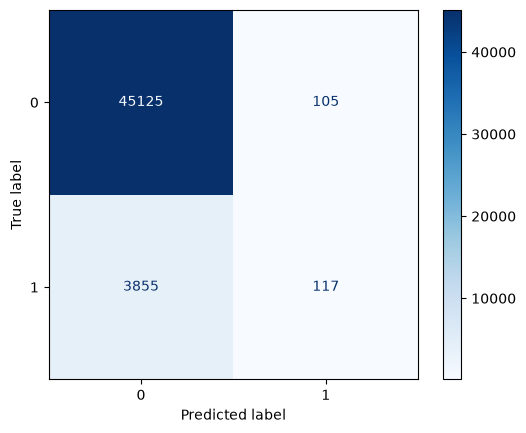

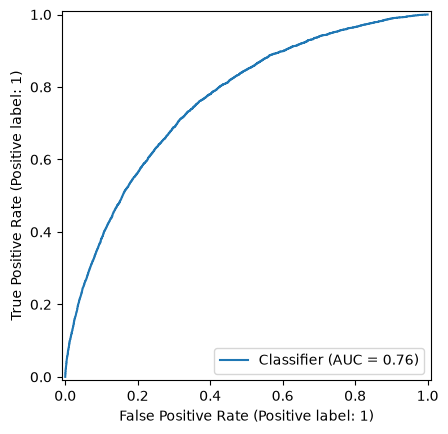

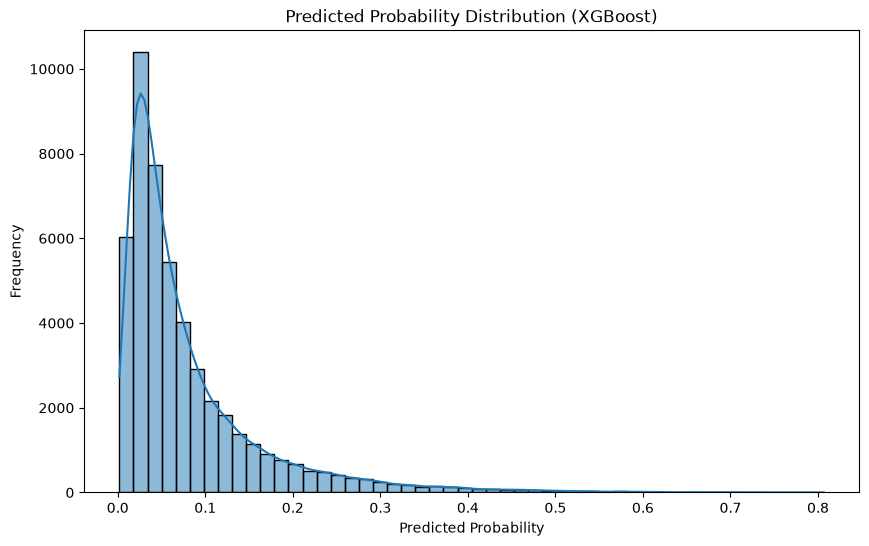

In [ ]:
# 3.1 MODEL EVALUATION
# XGBoost: Performance extraction
    # Metrics: ROC-AUC, PR-AUC, Accuracy, Precision, Recall, F1-Score
print("ROC-AUC:", roc_auc_score(y_val, y_prob_xgb))
print("PR-AUC:", average_precision_score(y_val, y_prob_xgb))
print("Accuracy:", accuracy_score(y_val, y_pred_xgb))
print("Precision:", precision_score(y_val, y_pred_xgb))
print("Recall:", recall_score(y_val, y_pred_xgb))
print("F1-Score:", f1_score(y_val, y_pred_xgb))

    # Confusion matrix
cm = confusion_matrix(y_val, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

    # ROC curve
RocCurveDisplay.from_predictions(y_val, y_prob_xgb)

    # Probability distribution
plt.figure(figsize=(10, 6))
sns.histplot(y_prob_xgb, bins=50, kde=True)
plt.title("Predicted Probability Distribution (XGBoost)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")



In [72]:
# KS-statistic
fpr, tpr, thresholds = roc_curve(y_val, y_prob_xgb)
ks_statistic = max(tpr - fpr)
print("KS-statistic:", ks_statistic)

KS-statistic: 0.39449549455073424


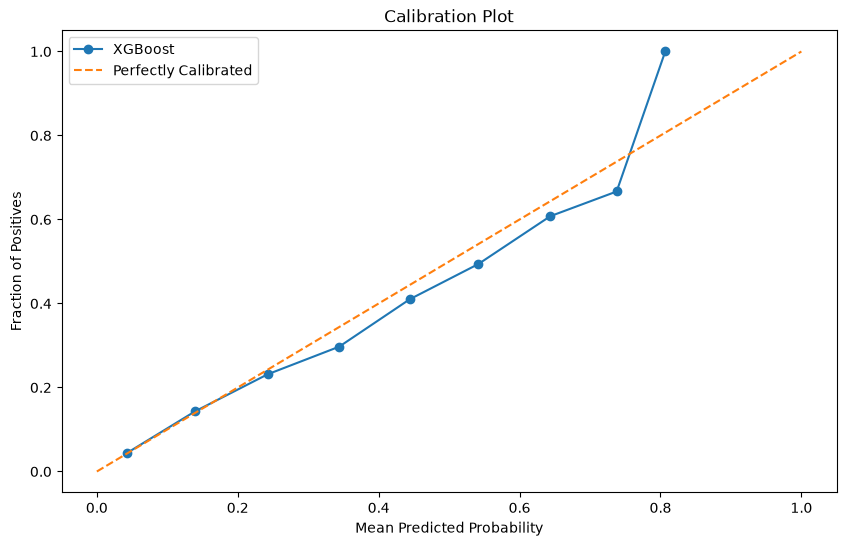

In [74]:
# Calibration plot
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_val, y_prob_xgb, n_bins=10)
plt.figure(figsize=(10, 6))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.title("Calibration Plot")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend()

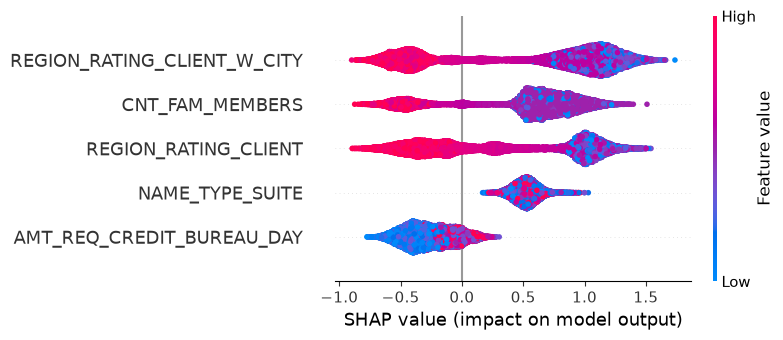

In [ ]:
# SHAP for XGBoost
explainer = shap.TreeExplainer(best_xgb.named_steps["model"])
shap_values = explainer(X_val_encoded)

    # Display SHAP summary plot for top 5 features
shap.summary_plot(shap_values, 
                  X_val_encoded,
                    max_display=5,
                    feature_names=X_val.columns)



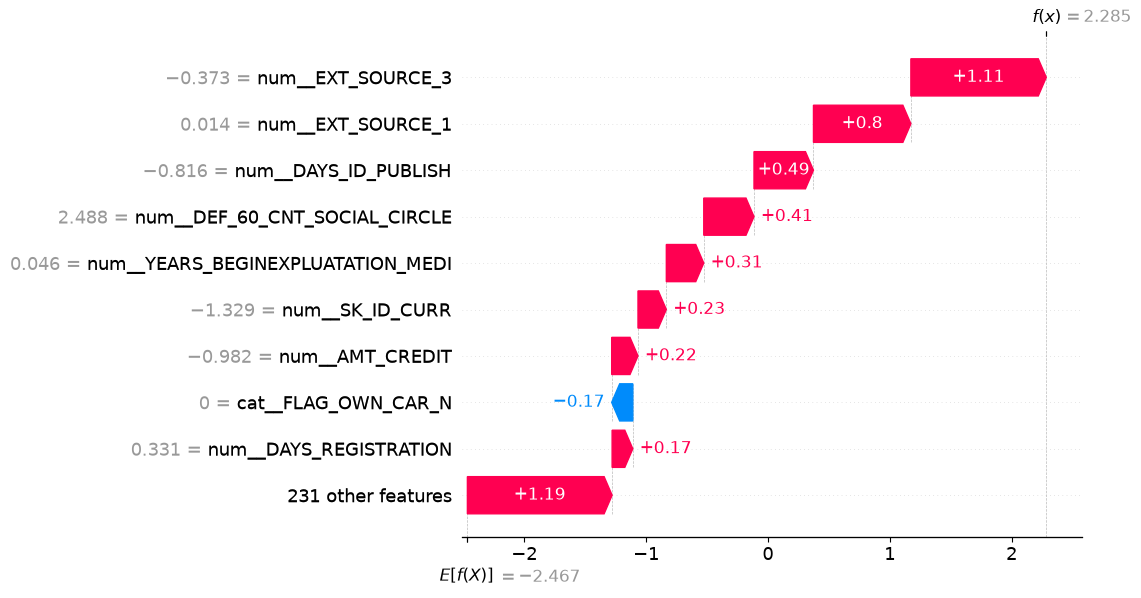

In [128]:
# Application simulation
feature_names = preprocessor.get_feature_names_out()
shap_values.feature_names = feature_names

    # Choose a random applicant 
i = 3
shap.plots.waterfall(
    shap_values[i],
    max_display=10
)

In [ ]:
# Performance by subgroup
X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
X_val["age_years"] = X_val["DAYS_BIRTH"] / 365.25

    # 1. Gender
roc_auc_gender = roc_auc_score(y_val, y_prob_xgb, sample_weight=(X_val["CODE_GENDER"] == "M").astype(int))
display("ROC-AUC for Male:", roc_auc_gender)
roc_auc_gender_female = roc_auc_score(y_val, y_prob_xgb, sample_weight=(X_val["CODE_GENDER"] == "F").astype(int))
display("ROC-AUC for Female:", roc_auc_gender_female)

    # 2. Age groups
X_val["age_group"] = pd.cut(X_val["DAYS_BIRTH"], bins=[0, 30, 40, 50, 60, 70, 80, 90, 100], labels=["<30", "30-39", "40-49", "50-59", "60-69", "70-79", "80-89", "90+"])
roc_auc_age_groups = X_val.groupby("age_group").apply(lambda x: roc_auc_score(y_val.loc[x.index], y_prob_xgb[x.index]))
print("ROC-AUC by Age Group:")
display(roc_auc_age_groups)

    # 3. Income levels
X_val["income_group"] = pd.qcut(X_val["AMT_INCOME_TOTAL"], q=4, labels=["Low", "Medium", "High", "Very High"])
roc_auc_income_groups = X_val.groupby("income_group").apply(lambda x: roc_auc_score(y_val.loc[x.index], y_prob_xgb[x.index]))
print("ROC-AUC by Income Group:")
display(roc_auc_income_groups)

    # 5. Education level
roc_auc_education = X_val.groupby("NAME_EDUCATION_TYPE").apply(lambda x: roc_auc_score(y_val.loc[x.index], y_prob_xgb[x.index]))
print("ROC-AUC by Education Level:")
display(roc_auc_education)

    # 6. Housing type
roc_auc_housing = X_val.groupby("NAME_HOUSING_TYPE").apply(lambda x: roc_auc_score(y_val.loc[x.index], y_prob_xgb[x.index]))
print("ROC-AUC by Housing Type:")
display(roc_auc_housing)  

    # 7. Marital status
roc_auc_marital = X_val.groupby("NAME_FAMILY_STATUS").apply(lambda x: roc_auc_score(y_val.loc[x.index], y_prob_xgb[x.index]))
print("ROC-AUC by Marital Status:")
display(roc_auc_marital)

    # 8. Occupation type
roc_auc_occupation = X_val.groupby("OCCUPATION_TYPE").apply(lambda x: roc_auc_score(y_val.loc[x.index], y_prob_xgb[x.index]))
print("ROC-AUC by Occupation Type:")
display(roc_auc_occupation)


'ROC-AUC for Male:'

0.7574866190943842

'ROC-AUC for Female:'

0.756301021814092

ROC-AUC by Age Group:


...

NAME_HOUSING_TYPE
Co-op apartment        0.744365
House / apartment      0.760994
Municipal apartment    0.753251
Office apartment       0.773247
Rented apartment       0.689798
With parents           0.770869
dtype: float64

ROC-AUC by Marital Status:


NAME_FAMILY_STATUS
Civil marriage          0.768856
Married                 0.763405
Separated               0.730106
Single / not married    0.757632
Widow                   0.730539
dtype: float64

ROC-AUC by Occupation Type:


OCCUPATION_TYPE
Accountants              0.744223
Cleaning staff           0.689940
Cooking staff            0.770379
Core staff               0.753839
Drivers                  0.726850
HR staff                 0.936709
High skill tech staff    0.742732
IT staff                 0.896552
Laborers                 0.756305
Low-skill Laborers       0.680195
Managers                 0.786927
Medicine staff           0.755570
Missing                  0.755824
Private service staff    0.657715
Realty agents            0.696396
Sales staff              0.748962
Secretaries              0.812030
Security staff           0.727104
Waiters/barmen staff     0.758014
dtype: float64

In [ ]:
# Model comparison
models_roc_auc = {
    "Logistic Regression": roc_auc_score(y_val, y_prob),
    "Random Forest": roc_auc_score(y_val, y_prob_rf),
    "XGBoost": roc_auc_score(y_val, y_prob_xgb),
    "Neural Network": roc_auc_score(y_val, y_prob_nn)
}

models_pr_auc = {
    "Logistic Regression": average_precision_score(y_val, y_prob),
    "Random Forest": average_precision_score(y_val, y_prob_rf),
    "XGBoost": average_precision_score(y_val, y_prob_xgb),
    "Neural Network": average_precision_score(y_val, y_prob_nn)
}

models_accuracy = {
    "Logistic Regression": accuracy_score(y_val, logreg_grid.predict(X_val_encoded)),
    "Random Forest": accuracy_score(y_val, best_rf.predict(X_val)),
    "XGBoost": accuracy_score(y_val, best_xgb.predict(X_val)),
    "Neural Network": accuracy_score(y_val, (y_prob_nn > 0.5).astype(int))
}


models_ks_statistic = {
    "Logistic Regression": max(roc_curve(y_val, y_prob)[1] - roc_curve(y_val, y_prob)[0]),
    "Random Forest": max(roc_curve(y_val, y_prob_rf)[1] - roc_curve(y_val, y_prob_rf)[0]),
    "XGBoost": max(roc_curve(y_val, y_prob_xgb)[1] - roc_curve(y_val, y_prob_xgb)[0]),
    "Neural Network": max(roc_curve(y_val, y_prob_nn)[1] - roc_curve(y_val, y_prob_nn)[0])
}

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    "Model": list(models_roc_auc.keys()),
    "ROC-AUC": list(models_roc_auc.values()),
    "PR-AUC": list(models_pr_auc.values()),
    "Accuracy": list(models_accuracy.values()),
    "KS-Statistic": list(models_ks_statistic.values())
})

display(comparison_df.sort_values(by="ROC-AUC", ascending=False))

,Model,ROC-AUC,PR-AUC,Accuracy,KS-Statistic
2,XGBoost,0.761831,0.242186,0.919515,0.394495
3,Neural Network,0.747628,0.227068,0.919292,0.365931
0,Logistic Regression,0.746653,0.226091,0.919251,0.369528
1,Random Forest,0.745236,0.217596,0.883013,0.372441


Income vs Default Risk
           Income  Default_Risk
0    69367.500000      0.082354
1    84663.947368      0.081056
2    99960.394737      0.080708
3   115256.842105      0.080557
4   130553.289474      0.080526
5   145849.736842      0.080551
6   161146.184211      0.080558
7   176442.631579      0.081168
8   191739.078947      0.081216
9   207035.526316      0.081168
10  222331.973684      0.081332
11  237628.421053      0.081153
12  252924.868421      0.080809
13  268221.315789      0.080405
14  283517.763158      0.080044
15  298814.210526      0.080079
16  314110.657895      0.080079
17  329407.105263      0.080430
18  344703.552632      0.080430
19  360000.000000      0.080516


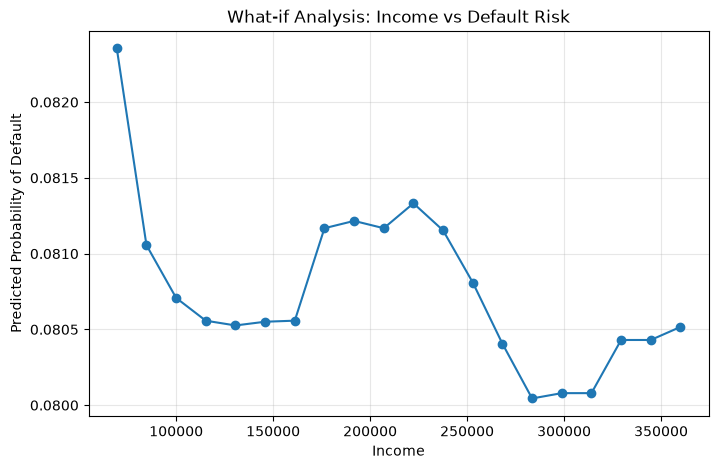

In [129]:
# What-if analysis
    # 1. Risk of default if income increases

scenario = X_test.copy()
income_values = np.linspace(
    X_test['AMT_INCOME_TOTAL'].quantile(0.05),
    X_test['AMT_INCOME_TOTAL'].quantile(0.95),
    20
)

default_risk = []

for income in income_values:
    temp = scenario.copy()
    temp['AMT_INCOME_TOTAL'] = income

    # Average predicted probability of default
    probability = best_xgb.predict_proba(temp)[:, 1].mean()
    default_risk.append(probability)


income_risk = pd.DataFrame({
    'Income': income_values,
    'Default_Risk': default_risk
})

print("Income vs Default Risk")
print(income_risk)

    # Plot
plt.figure(figsize=(8, 5))

plt.plot(
    income_risk['Income'],
    income_risk['Default_Risk'],
    marker='o'
)

plt.xlabel('Income')
plt.ylabel('Predicted Probability of Default')
plt.title('What-if Analysis: Income vs Default Risk')
plt.grid(alpha=0.3)
plt.show()